# The Backorder Monetization Engine

* **Domain:** Enterprise Supply Chain & Heavy Infrastructure
* **Objective:** Translate noisy ERP snapshots into probabilistic Safety Stock allocations.
* **Architecture Paradigm:** Cross-Sectional Time Series (Panel Data) with Cost-Sensitive Learning.

### THE MASTER BLUEPRINT
* **Phase 1: EDA & Data Physics** - Contract enforcement, Missing Not At Random (MNAR) analysis, and Target Imbalance verification.
* **Phase 2: The Signal Firewall** - Temporal Feature Engineering (Cross-sectional derivatives for memory/state abstraction).
* **Phase 3: The Utility Engine** - Modeling with Custom Cost-Sensitive Focal Loss (optimizing for NDCG).
* **Phase 4: The Safety Stock Engine** - Conformal Prediction for interval calibration and buffer allocation.

---

In [1]:
# ==============================================================================
# CELL 1: ARCHITECTURE SETUP & CONFIGURATION
# ==============================================================================
# --- 1. CORE IMPORTS ---
from __future__ import annotations
import os
from pathlib import Path
import warnings
import random

warnings.filterwarnings("ignore")

# --- Import the Enterprise Core Library ---
from supply_chain_pred_core import (SupplyChainUtils, MLArchitectureRouter, ColumnRole, FeatureContract,
                                    SemanticSchemaRegistry)


# --- 2. Centralized Configuration (Single Source of Truth) ---
class Config:
    """
    Immutable configuration parameters for the pipeline.
    """
    # Reproducibility
    SEED: int = 75

    # Path Management (Adapted for Kaggle/Local Hybrid)
    BASE_DIR: Path = Path.cwd().parent
    # Assuming dataset is in an 'input' or 'data' directory. Adjust locally if needed.
    DATA_DIR: Path = BASE_DIR / "data" / "backorder_prediction_dataset"
    TRAIN_FILE: Path = DATA_DIR / "Kaggle_Training_Dataset_v2.csv"
    TEST_FILE: Path = DATA_DIR / "Kaggle_Test_Dataset_v2.csv"

    # Target Definitions
    TARGET_COL: str = "went_on_backorder"
    ENTITY_COL: str = "sku"

    # Optimization Constants
    N_FOLDS = 5
    EWM_ALPHA: float = 0.3     # Decay factor for temporal abstraction
    COST_FN_WEIGHT: int = 50.0  # False Negative penalty multiplier for Custom Loss
    GAIN_THRESHOLD: float = 0.05
    OPT_N_TRAILS: int = 15
    N_BOOST_ROUNDS: int = 1500


# --- 3. Deterministic Environment Lock ---
os.environ["PYTHONHASHSEED"] = str(Config.SEED)
random.seed(Config.SEED)

# --- 4. Data ---
import numpy as np

np.random.seed(Config.SEED)

# External Frameworks & Display Engines
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display & Plot Configuration
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams.update(
        {"figure.figsize": (12, 5), "figure.dpi": 100, 'figure.max_open_warning': 0, "font.size": 11, "axes.grid": True,
                "grid.alpha": 0.3, "axes.titlesize": 13, "axes.labelsize": 11, "axes.unicode_minus": False, })
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)

print("[*] Core Library Imported Successfully. Environment Configured.")

[*] Core Library Imported Successfully. Environment Configured.


In [2]:
# ==============================================================================
# CELL 2: DATA INGESTION & AUTOMATED PROFILING
# ==============================================================================
print(f"[*] Loading raw train dataset ({Config.TRAIN_FILE}) from: {Config.DATA_DIR}")
df_raw = pd.read_csv(Config.DATA_DIR / Config.TRAIN_FILE, low_memory=False)

print(f"[*] Raw shape: {df_raw.shape}")

# ---------------------------------------------------------
# CLEANING PHYSICAL ARTIFACTS
# ---------------------------------------------------------
print("[*] Cleaning Data Artifacts (Converting -99 to NaN)...")
# The ERP system uses -99 to indicate "Unknown" supplier performance.
# We map this to NaN so LightGBM can use its native missing-node splits (MNAR strategy),
# and to prevent Semantic Bound violations.
df_raw.loc[df_raw['perf_6_month_avg'] < 0, 'perf_6_month_avg'] = np.nan
df_raw.loc[df_raw['perf_12_month_avg'] < 0, 'perf_12_month_avg'] = np.nan

# Convert Target to Binary immediately for profiling
df_raw[Config.TARGET_COL] = df_raw[Config.TARGET_COL].map({'Yes': 1, 'No': 0})
df_raw = df_raw.dropna(subset=[Config.TARGET_COL])

# Remove trailing rows with totally empty SKUs (Kaggle artifact)
df_raw = df_raw.dropna(subset=[Config.ENTITY_COL], how='all')

# ---------------------------------------------------------
# ROUTING & PROFILING
# ---------------------------------------------------------
print("[*] Launching Automated Architecture Router...")
# We tell the router which column represents velocity to check for Intermittent Demand
feature_candidates = [c for c in df_raw.columns if c not in [Config.TARGET_COL, Config.ENTITY_COL]]
router = MLArchitectureRouter(target_col=Config.TARGET_COL, velocity_col='sales_3_month')
blueprint = router.profile_and_route(df_raw, feature_cols=feature_candidates)

print("\n=== THE ML ARCHITECTURE BLUEPRINT ===")
print(f"-> Demand Type: {blueprint.demand_type}")
print(
    f"-> Missing Physics (MNAR): {len(blueprint.mnar_features)} features detected. Imputation banned on: {blueprint.mnar_features}")
print(f"-> Recommended Model: {blueprint.recommended_model}")
print(f"-> Recommended Objective: {blueprint.recommended_objective}")
print("=====================================\n")

# Optimize memory
df_raw = SupplyChainUtils.reduce_mem_usage(df_raw)

# Data Overview
SupplyChainUtils.dataset_health_check(df_raw)

[*] Loading raw train dataset (/home/nadavgordonbar/projects/Notebooks/data/backorder_prediction_dataset/Kaggle_Training_Dataset_v2.csv) from: /home/nadavgordonbar/projects/Notebooks/data/backorder_prediction_dataset
[*] Raw shape: (1687861, 23)
[*] Cleaning Data Artifacts (Converting -99 to NaN)...


[SC_Core] INFO: === INITIALIZING ENTERPRISE INGESTION PROFILING ===
[SC_Core] INFO: ADI Score: 1.82 -> Demand Type: Intermittent


[*] Launching Automated Architecture Router...


[SC_Core] INFO: MNAR Features detected (IMPUTATION BANNED): ['lead_time', 'perf_6_month_avg', 'perf_12_month_avg']
[SC_Core] INFO: === PROFILING COMPLETE. ROUTING DECISION LOCKED. ===
[SC_Core] INFO: Routing: GBDT (LightGBM) with Tweedie Variance | Drift: False | MNAR Feats: 3
[SC_Core] INFO: Memory usage reduced to 206.04 MB (33.3% reduction)



=== THE ML ARCHITECTURE BLUEPRINT ===
-> Demand Type: Intermittent
-> Missing Physics (MNAR): 3 features detected. Imputation banned on: ['lead_time', 'perf_6_month_avg', 'perf_12_month_avg']
-> Recommended Model: GBDT (LightGBM)
-> Recommended Objective: Tweedie Variance



,Dtype,Null_Count,Null_%,Unique_Values,Cardinality_%,min,25%,50%,75%,max,mean,std,Skewness
went_on_backorder,float32,0,0.0%,2,0.0%,0.000000,0.000000,0.000000,0.000000,1.000000,0.01,0.08,12.102385
perf_12_month_avg,float32,122050,7.2%,101,0.0%,0.000000,0.690000,0.830000,0.960000,1.000000,0.78,0.23,-1.617708
perf_6_month_avg,float32,129478,7.7%,101,0.0%,0.000000,0.700000,0.850000,0.970000,1.000000,0.78,0.24,-1.584979
lead_time,float32,100893,6.0%,32,0.0%,0.000000,4.000000,8.000000,9.000000,52.000000,7.87,7.06,4.556295
local_bo_qty,float32,0,0.0%,654,0.0%,0.000000,0.000000,0.000000,0.000000,12530.000000,0.63,33.72,165.190552
pieces_past_due,float32,0,0.0%,826,0.0%,0.000000,0.000000,0.000000,0.000000,146496.000000,2.04,236.02,412.391876
min_bank,float32,0,0.0%,5568,0.3%,0.000000,0.000000,0.000000,3.000000,313319.000000,52.77,1254.98,131.212646
in_transit_qty,float32,0,0.0%,5230,0.3%,0.000000,0.000000,0.000000,0.000000,489408.000000,44.05,1342.74,166.183395
sales_1_month,float32,0,0.0%,5764,0.3%,0.000000,0.000000,0.000000,4.000000,741774.000000,55.93,1928.20,196.119995
forecast_3_month,float32,0,0.0%,7825,0.5%,0.000000,0.000000,0.000000,4.000000,1427612.000000,178.12,5026.55,138.968323


,Dtype,Null_Count,Null_%,Unique_Values,Cardinality_%,min,25%,50%,75%,max,mean,std,Skewness
went_on_backorder,float32,0,0.0000,2,0.0001,0.0000,0.0000,0.0000,0.0000,1.0000,0.0067,0.0815,12.1024
perf_12_month_avg,float32,122050,7.2310,101,0.0060,0.0000,0.6900,0.8300,0.9600,1.0000,0.7770,0.2305,-1.6177
perf_6_month_avg,float32,129478,7.6711,101,0.0060,0.0000,0.7000,0.8500,0.9700,1.0000,0.7824,0.2370,-1.5850
lead_time,float32,100893,5.9776,32,0.0019,0.0000,4.0000,8.0000,9.0000,52.0000,7.8723,7.0560,4.5563
local_bo_qty,float32,0,0.0000,654,0.0387,0.0000,0.0000,0.0000,0.0000,12530.0000,0.6265,33.7222,165.1906
pieces_past_due,float32,0,0.0000,826,0.0489,0.0000,0.0000,0.0000,0.0000,146496.0000,2.0437,236.0165,412.3919
min_bank,float32,0,0.0000,5568,0.3299,0.0000,0.0000,0.0000,3.0000,313319.0000,52.7723,1254.9832,131.2126
in_transit_qty,float32,0,0.0000,5230,0.3099,0.0000,0.0000,0.0000,0.0000,489408.0000,44.0520,1342.7417,166.1834
sales_1_month,float32,0,0.0000,5764,0.3415,0.0000,0.0000,0.0000,4.0000,741774.0000,55.9261,1928.1958,196.1200
forecast_3_month,float32,0,0.0000,7825,0.4636,0.0000,0.0000,0.0000,4.0000,1427612.0000,178.1193,5026.5532,138.9683


In [3]:
# ==============================================================================
# CELL 3: GOVERNANCE & SEMANTIC SCHEMA REGISTRY
# ==============================================================================
print("[*] Initializing Semantic Schema Registry...")
global_schema_registry = SemanticSchemaRegistry(strict_mode=True)

# Define both RAW and ENGINEERED contracts for absolute governance
valmont_contracts = [
    # --- 1. The Core Entities ---
    FeatureContract(Config.ENTITY_COL, dependencies=[], dtype_family='categorical', role=ColumnRole.IDENTITY),
    FeatureContract(
        Config.TARGET_COL, dependencies=[], dtype_family='numeric', role=ColumnRole.TARGET, min_val=0, max_val=1),

    # --- 2. Raw Data Contracts (The foundation) ---
    FeatureContract('national_inv', dependencies=[], dtype_family='numeric'),
    FeatureContract('lead_time', dependencies=[], dtype_family='numeric', min_val=0.0),
    FeatureContract('in_transit_qty', dependencies=[], dtype_family='numeric', min_val=0.0),
    FeatureContract('sales_1_month', dependencies=[], dtype_family='numeric', min_val=0.0),
    FeatureContract('sales_3_month', dependencies=[], dtype_family='numeric', min_val=0.0),
    FeatureContract('sales_9_month', dependencies=[], dtype_family='numeric', min_val=0.0),
    FeatureContract('forecast_3_month', dependencies=[], dtype_family='numeric', min_val=0.0),
    FeatureContract('forecast_9_month', dependencies=[], dtype_family='numeric', min_val=0.0),
    FeatureContract('perf_6_month_avg', dependencies=[], dtype_family='numeric', min_val=0.0, max_val=1.0),
    FeatureContract('perf_12_month_avg', dependencies=[], dtype_family='numeric', min_val=0.0, max_val=1.0),

    # --- 3. Engineered Feature Contracts (The logic boundaries) ---
    FeatureContract('is_lead_time_missing', dependencies=['lead_time'], dtype_family='numeric', min_val=0, max_val=1),
    FeatureContract('sales_acceleration', dependencies=['sales_1_month', 'sales_9_month'], dtype_family='numeric'),
    FeatureContract(
        'sales_spike_ratio', dependencies=['sales_1_month', 'sales_9_month'],
        dtype_family='numeric', min_val=0.0),
    FeatureContract('forecast_acceleration', dependencies=['forecast_3_month', 'forecast_9_month'], dtype_family='numeric'),
    FeatureContract(
        'inventory_runway_periods', dependencies=['national_inv', 'sales_3_month'],
        dtype_family='numeric', min_val=None), # ERP allows negative stock
    FeatureContract(
        'critical_runway_flag', dependencies=['national_inv', 'sales_3_month'],
        dtype_family='numeric', min_val=0, max_val=1),
    FeatureContract(
        'transit_coverage_ratio', dependencies=['in_transit_qty', 'sales_3_month', 'lead_time'],
        dtype_family='numeric', min_val=0.0),
    FeatureContract(
        'supplier_degradation_score', dependencies=['perf_6_month_avg', 'perf_12_month_avg'],
        dtype_family='numeric', min_val=-1.0, max_val=1.0),
    FeatureContract(
        'severe_degradation_flag', dependencies=['perf_6_month_avg', 'perf_12_month_avg'],
        dtype_family='numeric', min_val=0, max_val=1)
]

global_schema_registry.register_contracts(valmont_contracts)

# Enforce pre-flight dependency check -> WE MUST CHECK THE ENGINEERED FEATURES
# This ensures that df_raw actually contains the base columns needed to build them.
engineered_features_to_build = [
    'is_lead_time_missing', 'sales_acceleration', 'sales_spike_ratio',
    'forecast_acceleration', 'inventory_runway_periods', 'critical_runway_flag',
    'transit_coverage_ratio', 'supplier_degradation_score', 'severe_degradation_flag'
]

if global_schema_registry.pre_flight_dependency_check(df_raw, target_features=engineered_features_to_build):
    print("[*] Pre-flight Dependency Check: PASSED. All base columns exist.")

# Type Casting based on Kaggle specifics
print("[*] Applying Dataset-Specific Type Casting...")
boolean_cols = ['potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop']
for col in boolean_cols:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].map({'Yes': 1, 'No': 0}).astype(np.int8)

global_schema_registry.capture_checkpoint(df_raw, checkpoint_name="raw_ingestion")
print("[*] Schema Checkpoint 'raw_ingestion' locked.")

[SemanticRegistry] INFO: Registered 21 explicit feature contracts.


[*] Initializing Semantic Schema Registry...
[*] Pre-flight Dependency Check: PASSED. All base columns exist.
[*] Applying Dataset-Specific Type Casting...


[SemanticRegistry] INFO: Captured reactive checkpoint 'raw_ingestion' | Features: 23


[*] Schema Checkpoint 'raw_ingestion' locked.


## PHASE 1: EXPLORATORY DATA PHYSICS & ARCHITECTURAL DECISIONS
Before engineering features or selecting models, we must construct a mathematical and physical
justification for our architecture. We analyze the raw ERP data across 4 dimensions:

### Chapter 1: The Physics of the Target (Extreme Imbalance)

**Hypothesis:**
Supply chains are optimized to prevent backorders. Failures should be exceedingly rare.

**Architectural Impact:**
If the imbalance is extreme (>1:100), standard metrics (Accuracy, ROC-AUC)
and standard objectives (LogLoss) will fail mathematically. We will require an asymmetric evaluation
framework and a cost-sensitive learning objective.

=== CHAPTER 1: TARGET IMBALANCE ===


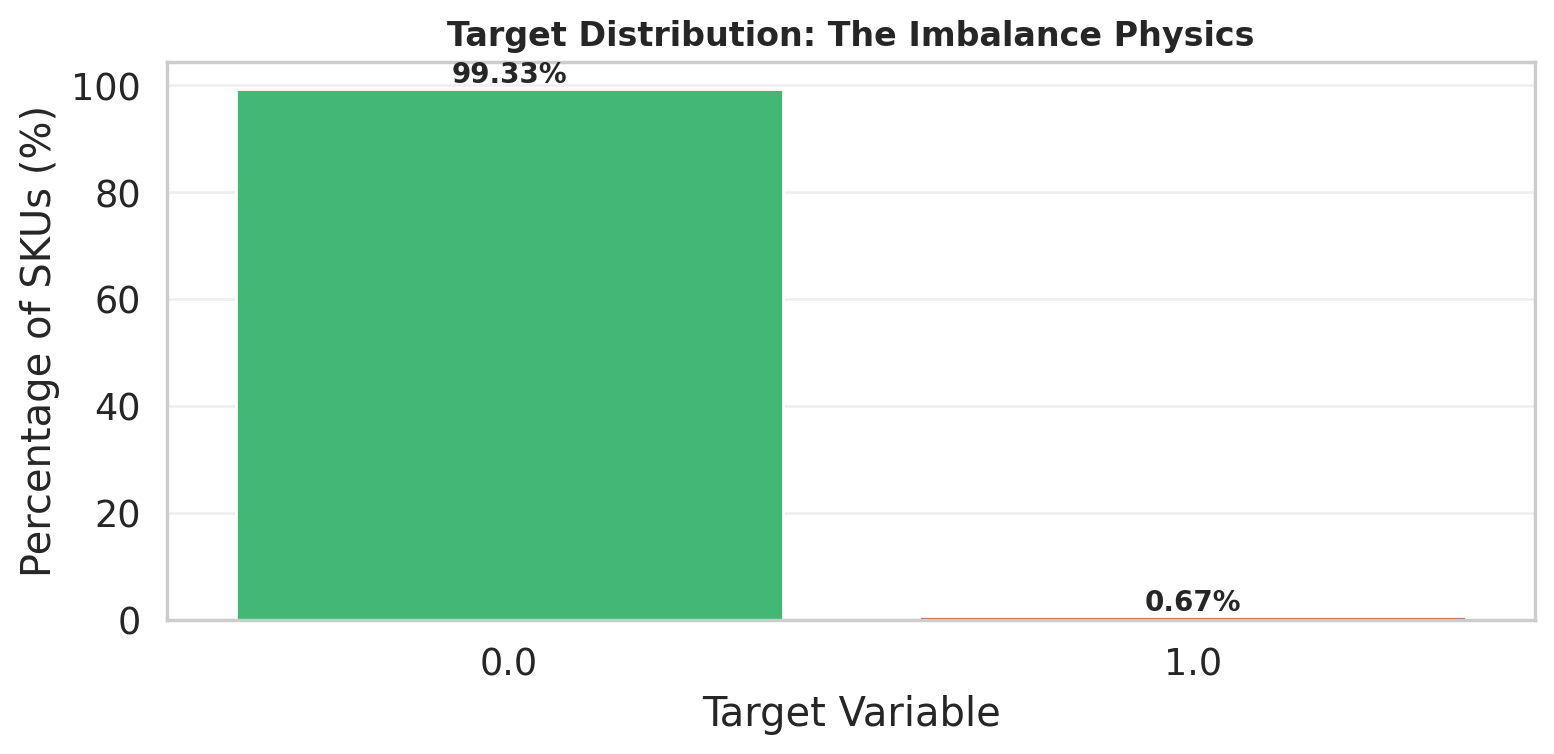

>>> ARCHITECTURAL DIRECTIVE:
    1. METRICS: ROC-AUC is banned. We will strictly use PR-AUC and NDCG@500.
    2. OBJECTIVE: Standard Cross-Entropy is banned. We must build a Custom Focal Loss.


In [4]:
# ==============================================================================
# CELL 4: Chapter 1: The Physics of the Target (Extreme Imbalance)
# ==============================================================================

# --- 1. THE IMBALANCE PROOF ---
print("=== CHAPTER 1: TARGET IMBALANCE ===")
SupplyChainUtils.plot_target_imbalance(df_raw, Config.TARGET_COL)

print(">>> ARCHITECTURAL DIRECTIVE:")
print("    1. METRICS: ROC-AUC is banned. We will strictly use PR-AUC and NDCG@500.")
print("    2. OBJECTIVE: Standard Cross-Entropy is banned. We must build a Custom Focal Loss.")

### Chapter 2: "The Silence of the Data" (Missing Not At Random)

**Hypothesis:**
In ERP systems, a missing `lead_time` is not a random clerical error. It usually indicates a new SKU that has never been ordered, or a locally manufactured part.

**Architectural Impact:**
If data is Missing Not At Random (MNAR), standard imputation (Mean/Median) destroys critical signal. We must use tree-based models (like LightGBM) that can route NaNs to a dedicated branch, treating 'Missing' as a distinct physical state.

=== MISSING DATA PHYSICS: LEAD_TIME ===
Missing Values: 100,893 (5.98%)
Risk when value is PRESENT: 0.6912%
Risk when value is MISSING: 0.3211%
Risk Multiplier (Missing vs Present): 0.46x
>>> CONCLUSION: 'lead_time' exhibits MNAR behavior. Imputation is prohibited.


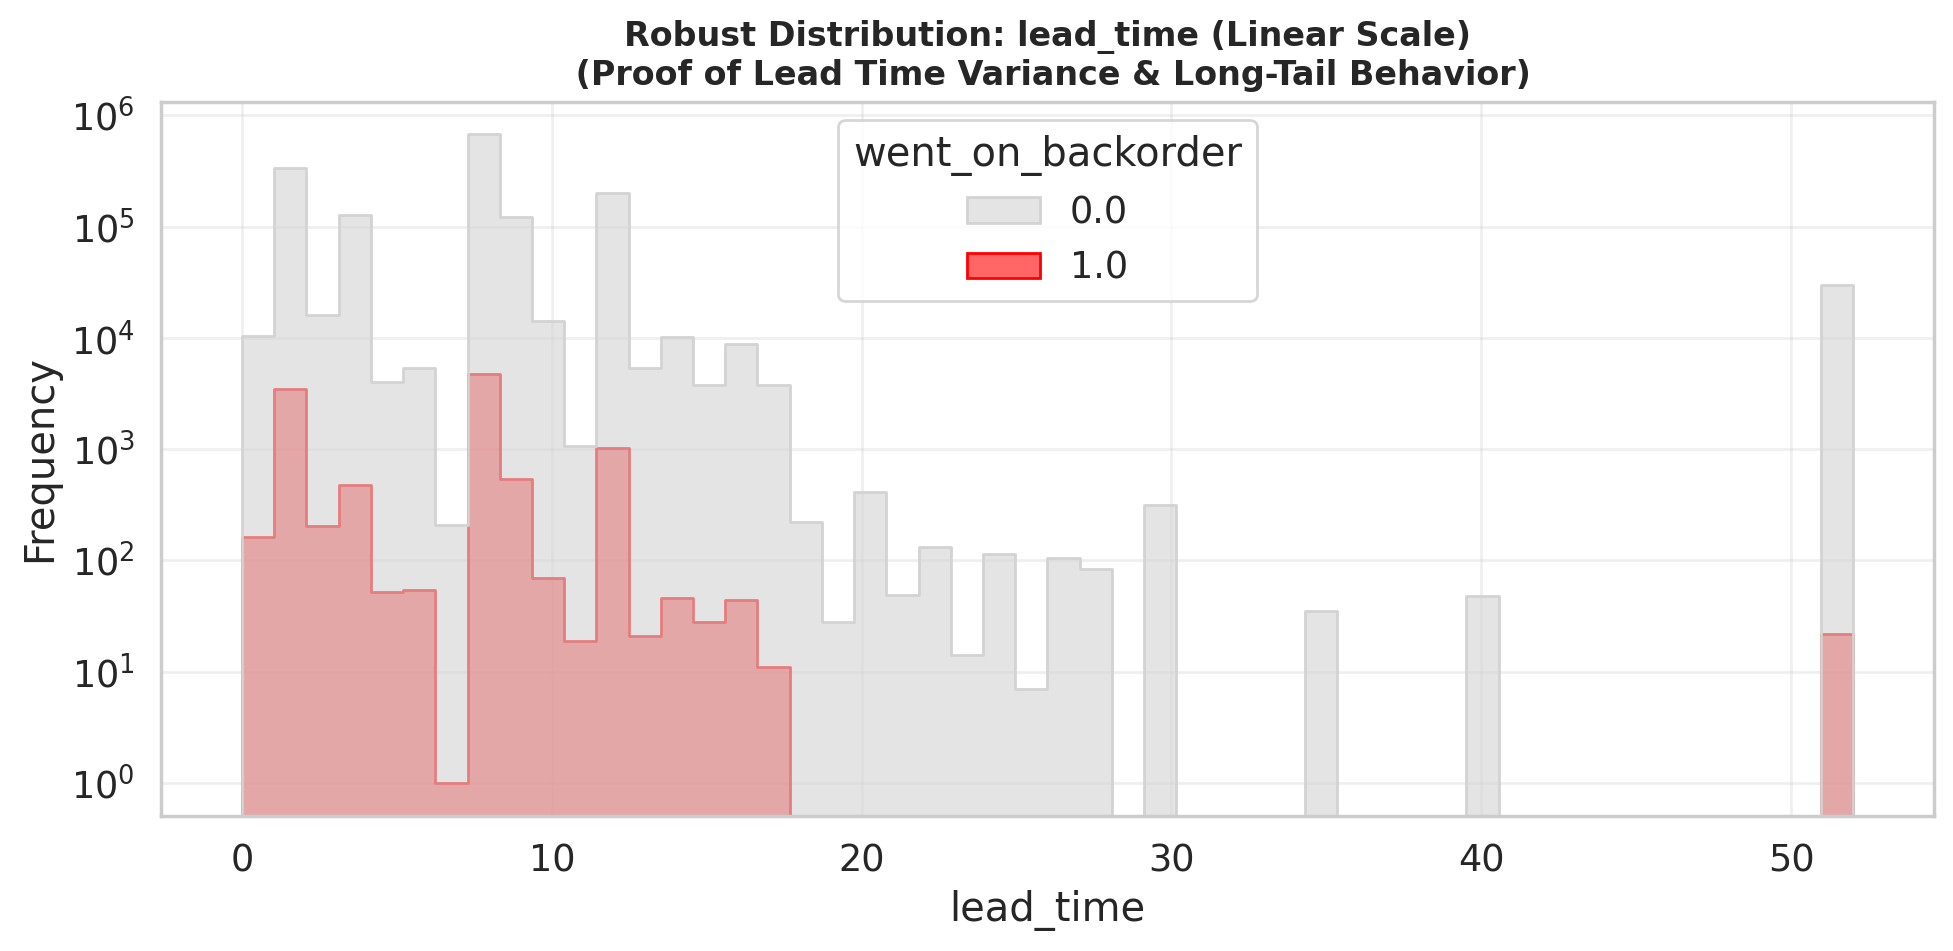

In [5]:
# ==============================================================================
# CELL 5: Chapter 2: "The Silence of the Data" (Missing Not At Random)
# ==============================================================================

# --- 2. MNAR ANALYSIS ---
SupplyChainUtils.print_mnar_physics_report(df_raw, Config.TARGET_COL, 'lead_time')

SupplyChainUtils.plot_robust_distribution(
    df=df_raw, col='lead_time', target=Config.TARGET_COL, log_scale=False, cnt_log_scale=True,
    title_suffix=" (Proof of Lead Time Variance & Long-Tail Behavior)")

### Chapter 3: The Danger Zone (Cross-Sectional Snapshots)

**Hypothesis:**
We only have a static snapshot of the database. Backorders physically occur when `national_inv` drops dangerously close to `min_bank`.

**Architectural Impact:**
Because we lack temporal logs (Time Series), the model cannot see inventory draining. We must actively engineer "temporal derivatives" (e.g., Runway = Inventory / Velocity) to simulate the passage of time.


=== CHAPTER 3: INVENTORY PHYSICS (THE DANGER ZONE) ===


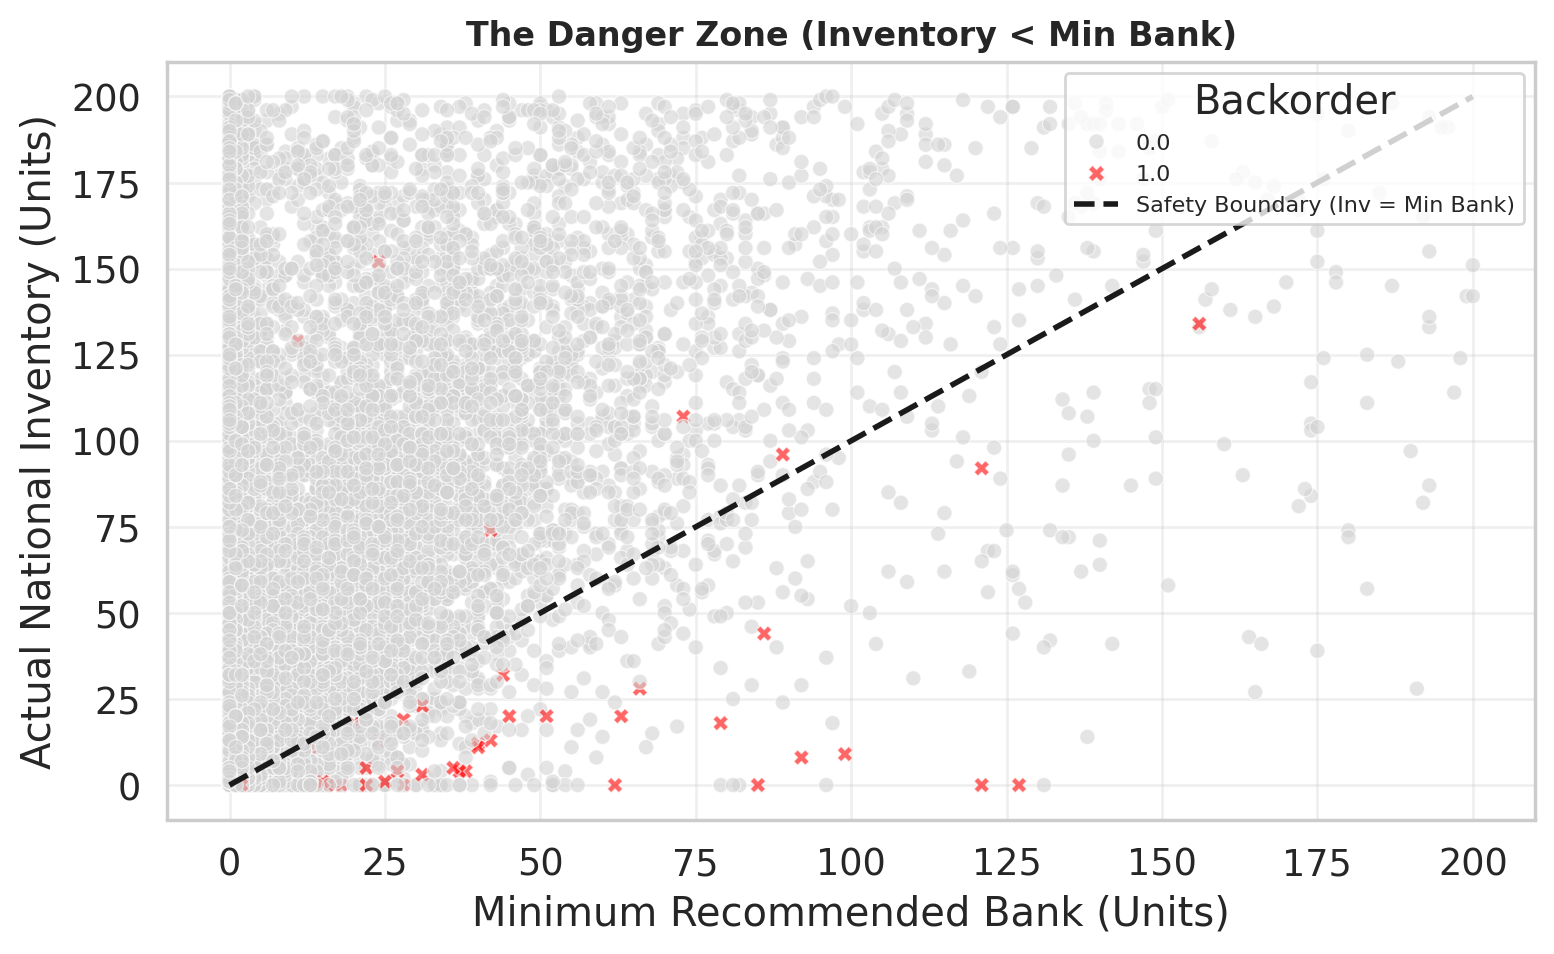

>>> ARCHITECTURAL DIRECTIVE:
    We must engineer `inventory_runway_months` and `critical_runway_flag` to capture this physical boundary.


In [6]:
# ==============================================================================
# CELL 6: Chapter 3: The Danger Zone (Cross-Sectional Snapshots)
# ==============================================================================

# --- 3. THE DANGER ZONE ---
print("\n=== CHAPTER 3: INVENTORY PHYSICS (THE DANGER ZONE) ===")
SupplyChainUtils.plot_danger_zone(df_raw, Config.TARGET_COL, x_col='min_bank', y_col='national_inv', seed=Config.SEED)

print(">>> ARCHITECTURAL DIRECTIVE:")
print("    We must engineer `inventory_runway_months` and `critical_runway_flag` to capture this physical boundary.")

### Chapter 4: Human Heuristics vs. Mathematical Reality

**Hypothesis:**
Boolean flags created by human operators (e.g., `deck_risk`, `potential_issue`) contain strong priors but are likely noisy.

**Architectural Impact:**
We must validate if these heuristics hold weight. If variance is high, we will need Unsupervised Dimensionality Reduction (GMM Archetyping) to group chaotic human flags into stable behavioral clusters.


=== CHAPTER 4: HUMAN HEURISTIC VALIDATION ===


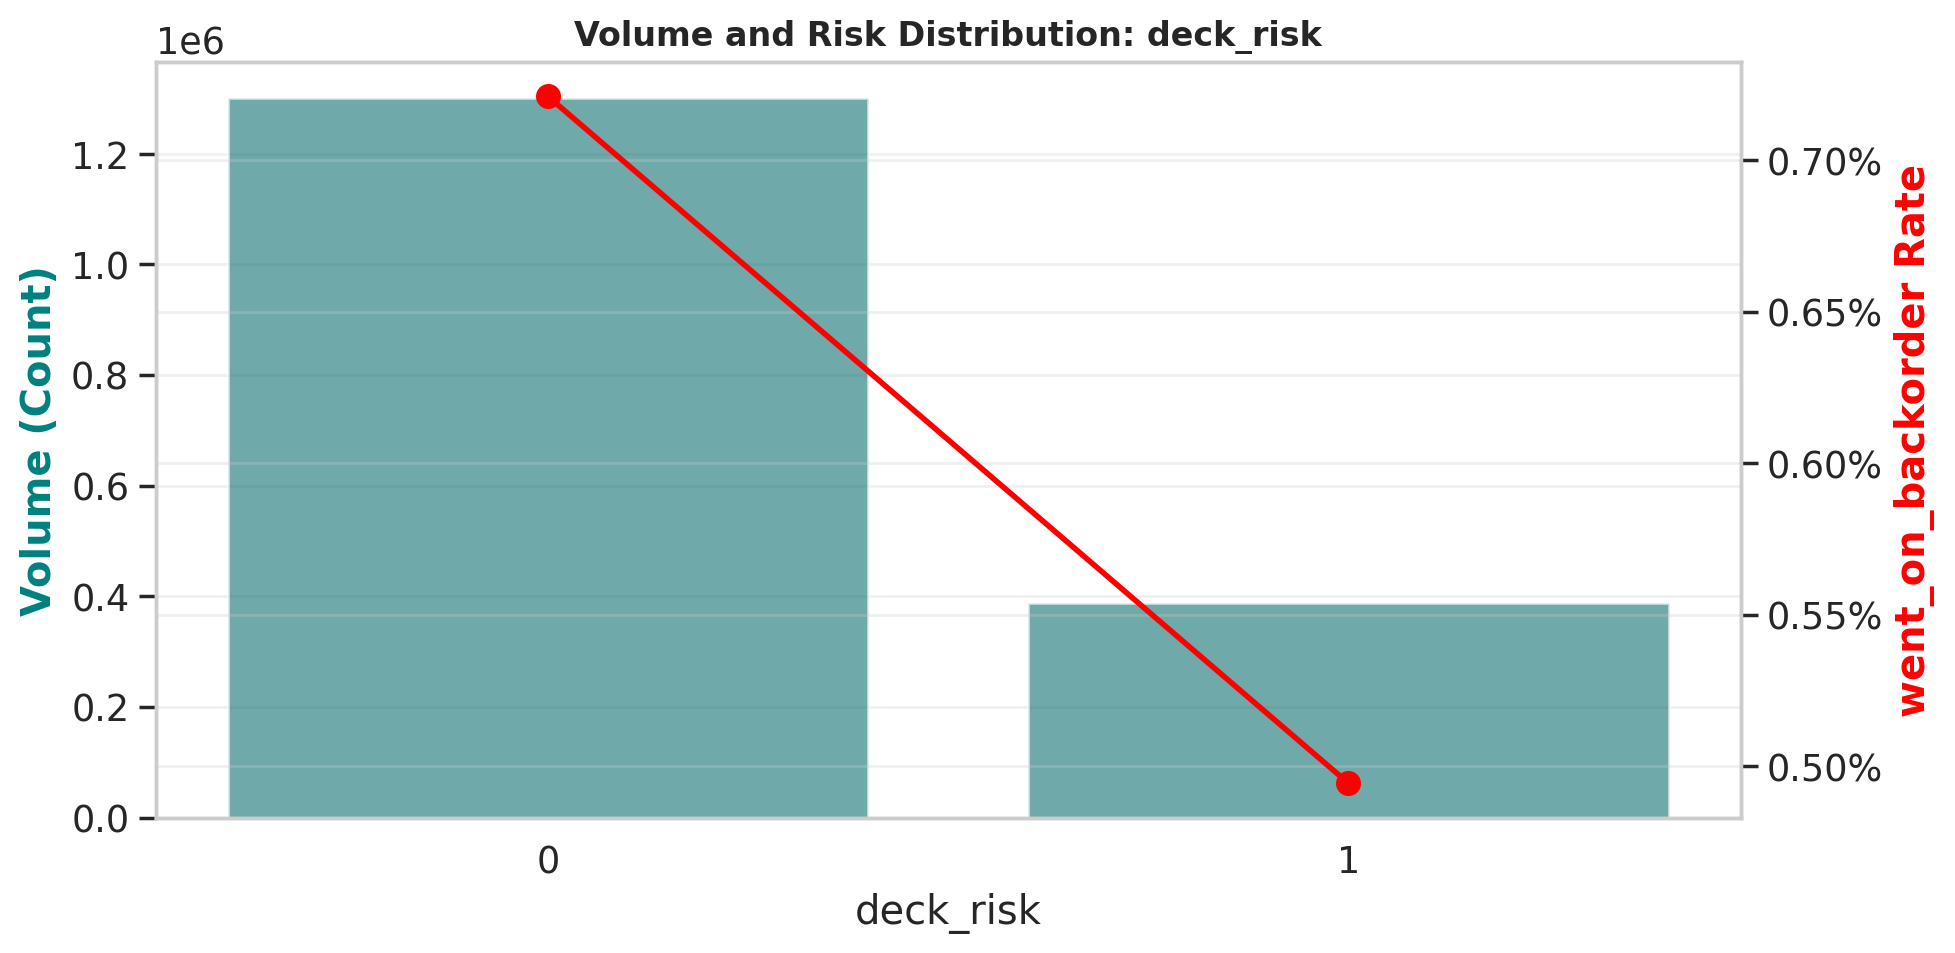

>>> ARCHITECTURAL DIRECTIVE:
    Human flags show correlation but high false-positive volume. We will use GMM Archetyping.


In [7]:
# ==============================================================================
# CELL 7: Chapter 4: Human Heuristics vs. Mathematical Reality
# ==============================================================================

# --- 4. BOOLEAN HEURISTIC VALIDATION ---
print("\n=== CHAPTER 4: HUMAN HEURISTIC VALIDATION ===")
SupplyChainUtils.plot_categorical_distribution(df_raw, col='deck_risk', top_k=2, target=Config.TARGET_COL)

print(">>> ARCHITECTURAL DIRECTIVE:")
print("    Human flags show correlation but high false-positive volume. We will use GMM Archetyping.")

### Chapter 5: Feature Prototyping (Raw vs. Engineered Signal)

**Do domain-specific ratios separate the classes better than raw ERP metrics?**

We will test two concepts:
1. **Runway vs. Absolute Stock:** Is "Months of Inventory Left" a stronger signal than "Total Units in Warehouse"?
2. **Contextual Transit (The "Naive" Feature failure):** Does knowing how much stock is on a ship (`in_transit_qty`) help, or do we only care about how long that transit stock will sustain us?


=== CHAPTER 5: FEATURE PROTOTYPING (RAW VS DERIVATIVE) ===


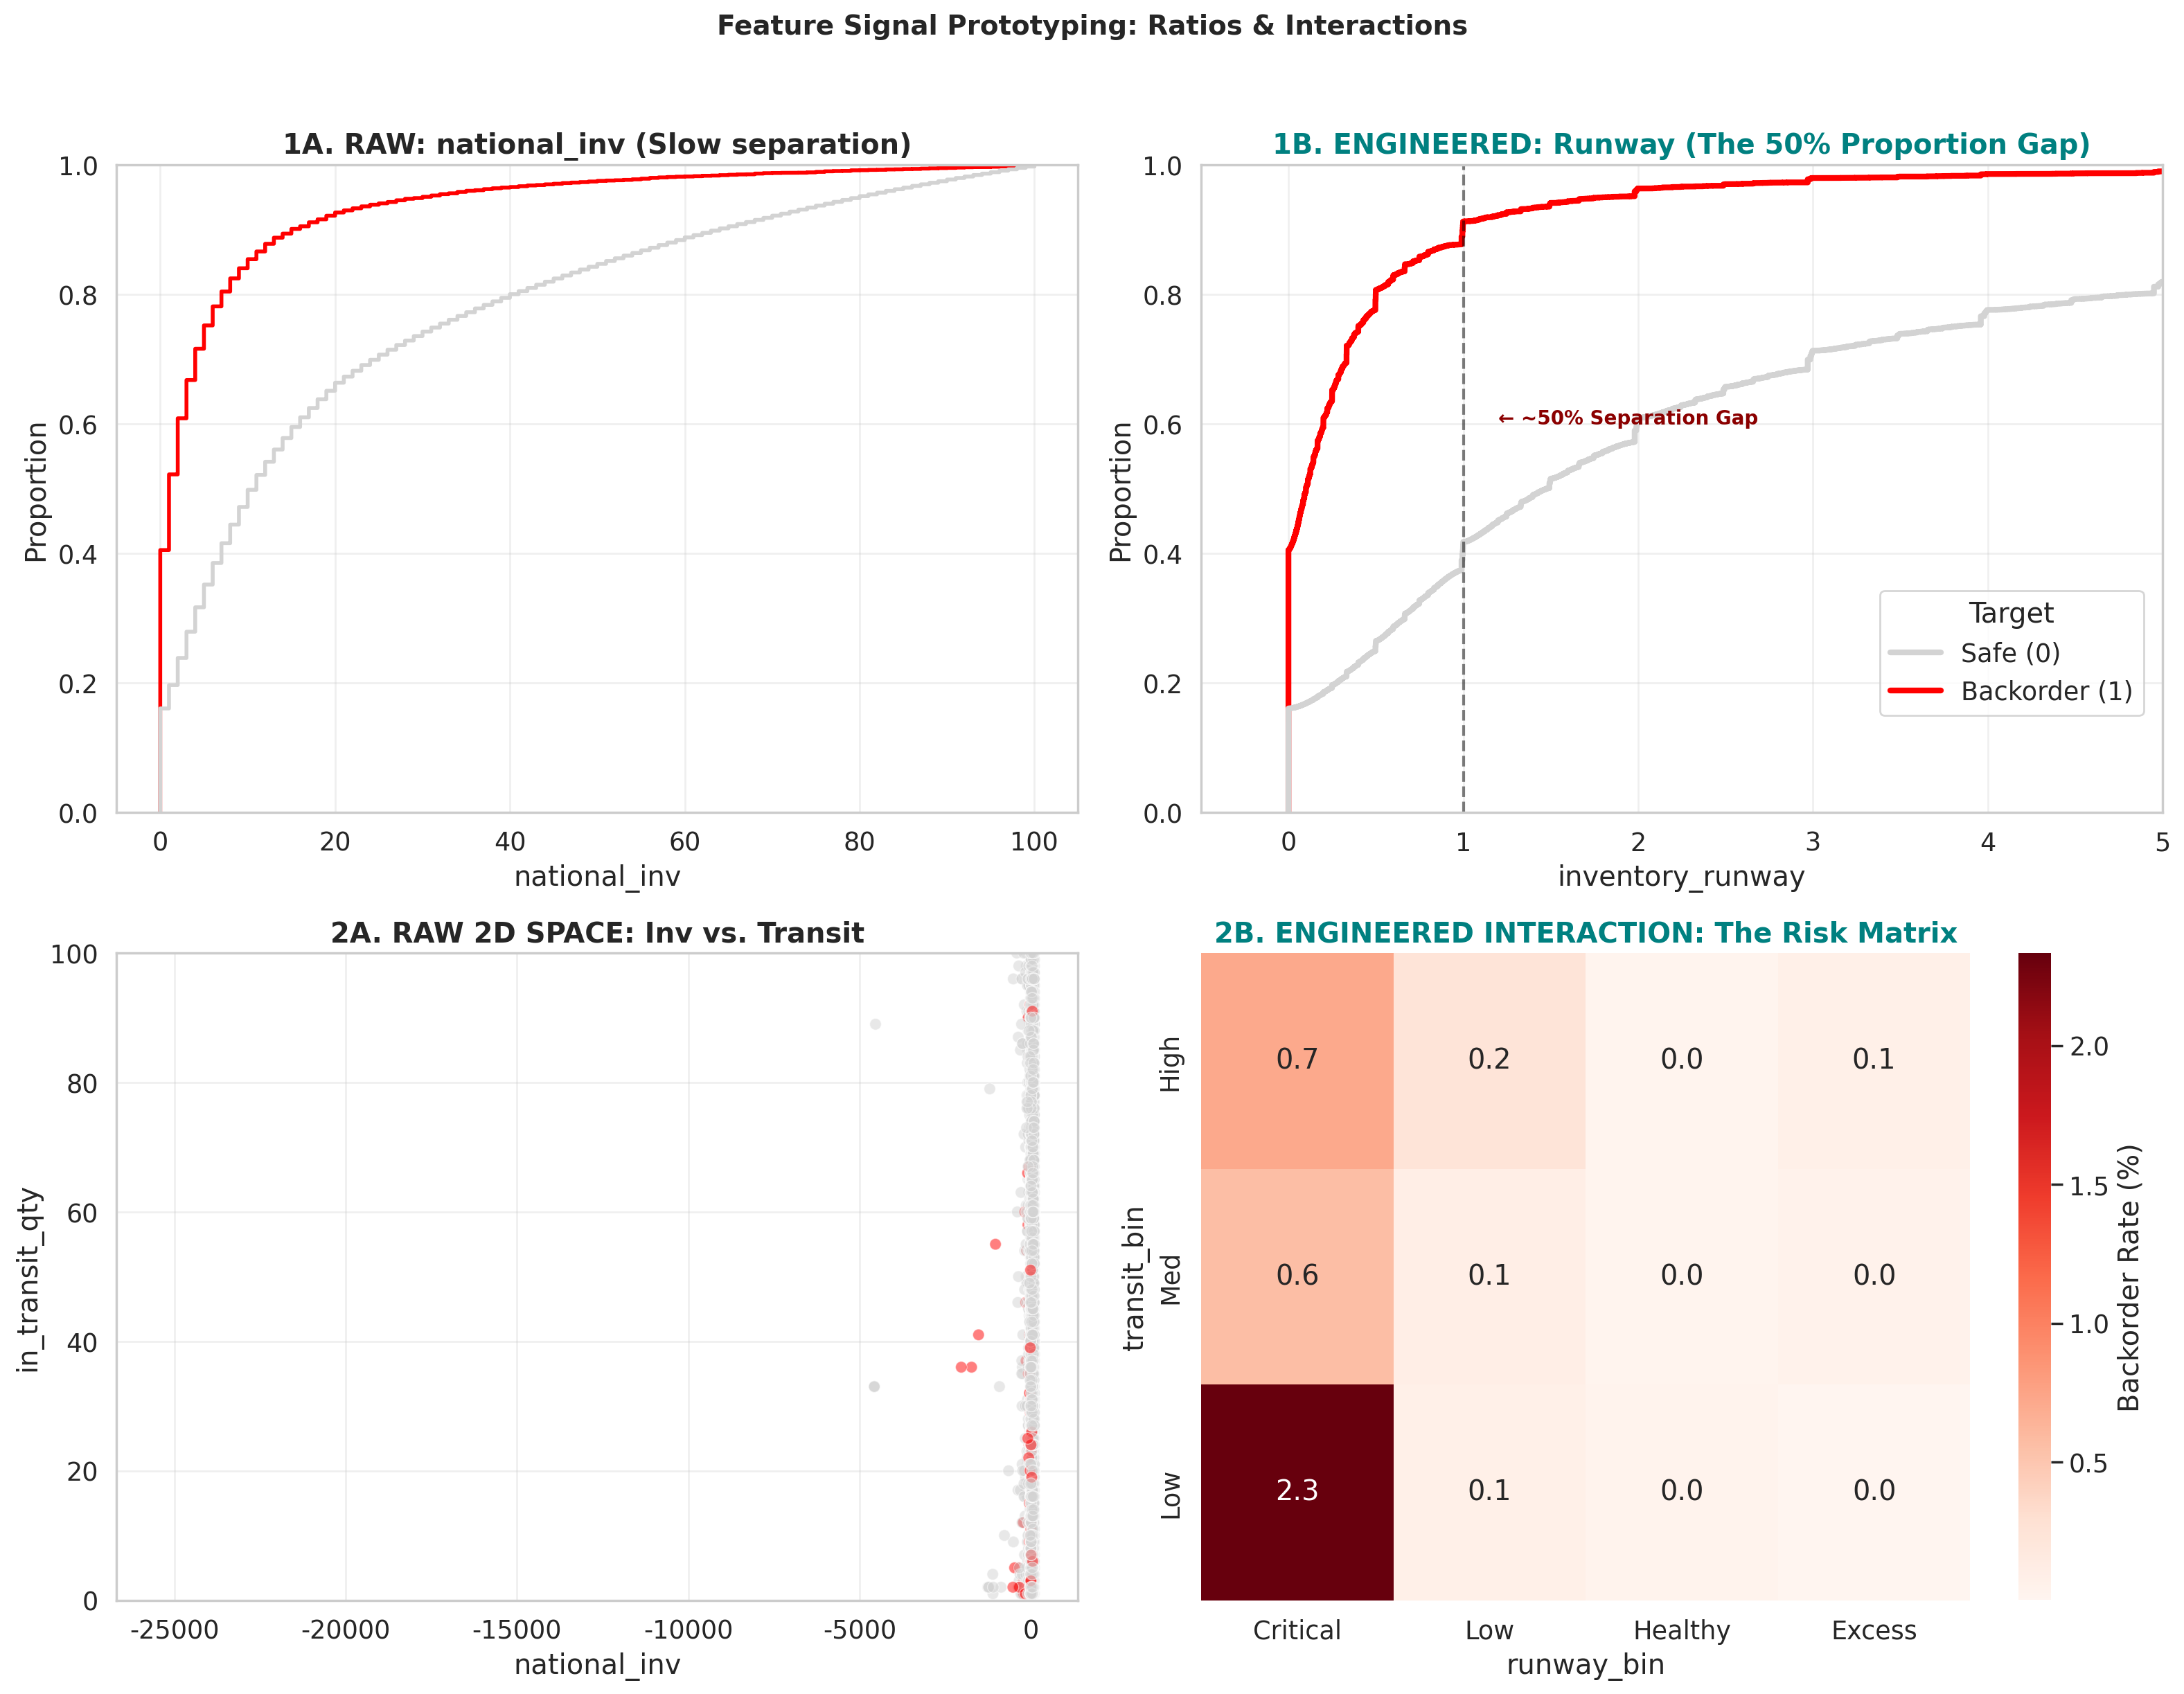

>>> ARCHITECTURAL DIRECTIVES & HYPOTHESES FOR NEXT PHASES:
    1. THE NORMALIZATION HYPOTHESIS (Row 1):
       - Observation: Raw inventory features contain valid baseline signal and must be retained.
         However, normalizing static units by flow rates (Velocity) into temporal dimensions (Runway) yields sharper empirical distributions.
       - Action: Engineer a suite of temporal cross-sectional derivatives and test their predictive Lift against a raw benchmark.

    2. THE MULTIVARIATE INTERACTION CONSTRAINT (Row 2):
       - Observation: Univariate flow metrics (Transit) show weak isolated separation (2A). Conversely, the 2D Risk Matrix (2B)
         reveals a compounded non-linear risk multiplier (Lift) when intersecting critical limits of multiple dimensions.
       - Action: Mandates the exploration of interaction features and strongly indicates the necessity of hierarchical, 
         tree-based modeling architectures over flat linear models.

    3. ARCHETYPAL RISK REGIONS

In [8]:
# ==============================================================================
# CELL 8: Chapter 5: Feature Prototyping (Raw vs. Engineered Signal)
# ==============================================================================

# --- 5. FEATURE PROTOTYPING & SIGNAL VALIDATION ---
print("\n=== CHAPTER 5: FEATURE PROTOTYPING (RAW VS DERIVATIVE) ===")
SupplyChainUtils.plot_feature_prototyping_proofs(df_raw, target_col=Config.TARGET_COL, inv_col='national_inv',
        velocity_col='sales_3_month', transit_col='in_transit_qty')

print(">>> ARCHITECTURAL DIRECTIVES & HYPOTHESES FOR NEXT PHASES:")
print("    1. THE NORMALIZATION HYPOTHESIS (Row 1):")
print("       - Observation: Raw inventory features contain valid baseline signal and must be retained.")
print(
    "         However, normalizing static units by flow rates (Velocity) into temporal dimensions (Runway) yields sharper empirical distributions.")
print(
    "       - Action: Engineer a suite of temporal cross-sectional derivatives and test their predictive Lift against a raw benchmark.")
print("")
print("    2. THE MULTIVARIATE INTERACTION CONSTRAINT (Row 2):")
print(
    "       - Observation: Univariate flow metrics (Transit) show weak isolated separation (2A). Conversely, the 2D Risk Matrix (2B)")
print(
    "         reveals a compounded non-linear risk multiplier (Lift) when intersecting critical limits of multiple dimensions.")
print(
    "       - Action: Mandates the exploration of interaction features and strongly indicates the necessity of hierarchical, ")
print("         tree-based modeling architectures over flat linear models.")
print("")
print("    3. ARCHETYPAL RISK REGIONS (Heatmap Topology):")
print(
    "       - Observation: The distinct localization of risk within specific fulfillment-vs-demand coverage vectors suggests ")
print("         the presence of latent operational states.")
print(
    "       - Action: Validates the upcoming strategy to evaluate Unsupervised Clustering (GMM Archetyping) to capture ")
print("         discrete supply chain risk profiles alongside continuous variable engineering.")

## PHASE 2: THE SIGNAL FIREWALL (Feature Engineering)
We translate raw ERP columns into physical supply chain derivatives (Runway, Acceleration, Degradation)
using our Core generic engineer, mapping the Kaggle-specific schema to the engine.

In [9]:
# ==============================================================================
# CELL 9: CROSS-SECTIONAL FEATURE ENGINEERING & ARCHETYPING (STRICT PATTERN)
# ==============================================================================
from supply_chain_pred_core import CrossSectionalDerivativeEngineer, SKUDensityArchetyper

print("[*] Instantiating Domain-Generic Feature Engineer...")

# 1. STEP ONE: Generate the Base Derivatives
engineer = CrossSectionalDerivativeEngineer(
    inventory_col='national_inv',
    velocity_col=('sales_3_month', 3.0),
    lead_time_col=('lead_time', 30.0),
    transit_col='in_transit_qty',
    sales_mapping={'short': ('sales_1_month', 1.0), 'long': ('sales_9_month', 9.0)},
    forecast_mapping={'short': ('forecast_3_month', 3.0), 'long': ('forecast_9_month', 9.0)},
    performance_mapping={'short': ('perf_6_month_avg', 1.0), 'long': ('perf_12_month_avg', 1.0)}
)

df_engineered = engineer.fit_transform(df_raw)
print(f"[*] Derivative Engineering Complete. Shape: {df_engineered.shape}")


# 2. STEP TWO: The Strict Archetyping Pattern
print("\n[*] Enforcing Strict Pattern for Behavioral Archetyping...")

# We cluster based on the *engineered derivatives*, not raw numbers!
behavioral_features = [
    'inventory_runway_periods',
    'transit_coverage_ratio',
    'supplier_degradation_score',
    'sales_spike_ratio'
]

n_clusters = 5

# Contract Definition for the newly born concept
archetype_contract = FeatureContract(
    name='sku_archetype_id',
    dependencies=behavioral_features,
    dtype_family='categorical',
    role=ColumnRole.FEATURE,
    min_val=0,
    max_val=n_clusters - 1,
    description="GMM-based behavioral cluster ID representing the SKU's supply chain archetype."
)

# Register & Pre-Flight
global_schema_registry.register_contracts([archetype_contract])
global_schema_registry.pre_flight_dependency_check(df_engineered, target_features=[archetype_contract.name])

# Fit & Transform
archetyper = SKUDensityArchetyper(numeric_features=behavioral_features, n_components=n_clusters, random_state=Config.SEED)
df_engineered = archetyper.fit_transform(df_engineered)

# 3. STEP THREE: Post-Flight Validation for the entire dataset
print("\n[*] Validating Output against Semantic Bounds...")
global_schema_registry.validate_semantic_bounds(df_engineered)
global_schema_registry.capture_checkpoint(df_engineered, checkpoint_name="post_archetyping_train")

print("[*] SKU Dimensionality Successfully Reduced. Pipeline Locked.")

[SemanticRegistry] INFO: Registered 1 explicit feature contracts.


[*] Instantiating Domain-Generic Feature Engineer...
[*] Derivative Engineering Complete. Shape: (1687860, 32)

[*] Enforcing Strict Pattern for Behavioral Archetyping...


[SemanticRegistry] INFO: All features successfully passed semantic bound validation.
[SemanticRegistry] INFO: Captured reactive checkpoint 'post_archetyping_train' | Features: 33



[*] Validating Output against Semantic Bounds...
[*] SKU Dimensionality Successfully Reduced. Pipeline Locked.


## PHASE 3: THE UTILITY ENGINE (Surrogate Pruning & Vitality)
Before deep optimization, we run a fast surrogate model to prune 'dead' features
that offer zero Information Gain, ensuring the final Optuna search space is dense and efficient.

In [10]:
# ==============================================================================
# CELL 10: FEATURE VITALITY & SURROGATE PRUNING
# ==============================================================================
from supply_chain_pred_core import SupplyChainModelTrainer, SupplyChainObjectives, SupplyChainUtils

metadata_cols = [Config.ENTITY_COL, Config.TARGET_COL]
feature_cols = [c for c in df_engineered.columns if c not in metadata_cols]

X = df_engineered[feature_cols].copy()
y = df_engineered[Config.TARGET_COL].copy()
categorical_features = ['sku_archetype_id'] if 'sku_archetype_id' in X.columns else []

print("[*] Computing Data-Driven Business Weights (ROI Proxy)...")
sample_weights = SupplyChainModelTrainer.compute_dynamic_weights(X['sales_3_month'])

print("[*] Initializing MLOps Trainer for Surrogate Phase...")
# Notice how clean this is: No massive cross-validation loops in the notebook!
trainer = SupplyChainModelTrainer(
    objective_func=SupplyChainObjectives.asymmetric_focal_loss,
    eval_metric_func=None, # Not needed for the quick surrogate pruning
    is_time_series=False,  # Snapshot data
    n_splits=Config.N_FOLDS,
    random_state=Config.SEED
)

# Run the automated pruning (Takes care of train/val splitting and training internally)
vital_features = trainer.run_surrogate_pruning(
    X, y, sample_weights, categorical_cols=categorical_features, gain_threshold=Config.GAIN_THRESHOLD,
)

X_vital = X[vital_features]
active_categorical = [c for c in categorical_features if c in vital_features]

# Lock the optimized schema
df_vital_checkpoint = X_vital.copy()
df_vital_checkpoint[Config.TARGET_COL] = y
global_schema_registry.capture_checkpoint(df_vital_checkpoint, "post_feature_selection")

print("\n[*] Classical Statistical Vitality Report (Surviving Features):")
vitality_df = SupplyChainUtils.generate_feature_vitality_report(X_vital, y, active_categorical)

try:
    from IPython.display import display
    display(vitality_df.head(10))
except ImportError:
    print(vitality_df.head(10))

[SC_Core] INFO: [*] Running Surrogate Model for Feature Vitality Assessment...


[*] Computing Data-Driven Business Weights (ROI Proxy)...
[*] Initializing MLOps Trainer for Surrogate Phase...


[SC_Core] INFO: [*] Pruned 5 dead features. Retained 26 vital features.
[SemanticRegistry] INFO: Captured reactive checkpoint 'post_feature_selection' | Features: 27



[*] Classical Statistical Vitality Report (Surviving Features):


,Feature,Cohens_D,Direction,Univariate_PR_AUC,Lift_vs_Baseline
0,inventory_runway_periods,0.0176,Negative,0.0472,7.0501
4,national_inv,0.0161,Negative,0.0370,5.5356
2,critical_runway_flag,2.1262,Positive,0.0370,5.5264
7,forecast_acceleration,0.0370,Positive,0.0189,2.8177
6,sales_spike_ratio,0.6095,Positive,0.0144,2.1547
18,local_bo_qty,0.1166,Positive,0.0136,2.0272
15,sales_acceleration,0.0080,Positive,0.0122,1.8188
13,perf_12_month_avg,0.3368,Negative,0.0100,1.4973
10,perf_6_month_avg,0.3405,Negative,0.0100,1.4945
21,pieces_past_due,0.0063,Positive,0.0096,1.4349


## PHASE 4: BAYESIAN OPTIMIZATION & ENSEMBLE TRAINING
We optimize our custom Focal Loss using Optuna, and then train a robust Cross-Validation Ensemble.
The MLOps Trainer automatically extracts Out-Of-Fold (OOF) predictions for our final calibration.

In [11]:
# ==============================================================================
# CELL 11: HYPERPARAMETER OPTIMIZATION (OPTUNA)
# ==============================================================================
from supply_chain_pred_core import SupplyChainEvaluationMetrics

print("[*] Initializing Dual-Metric Evaluator (NDCG & Financial Cost)...")
evaluator = SupplyChainEvaluationMetrics(fn_cost=Config.COST_FN_WEIGHT, fp_cost=1.0, k_ndcg=500)

print("[*] Re-initializing Trainer with Full Evaluation Metrics...")
trainer = SupplyChainModelTrainer(
    objective_func=SupplyChainObjectives.asymmetric_focal_loss,
    eval_metric_func=evaluator.cost_ndcg_dual_eval,
    is_time_series=False,  # Snapshot data
    n_splits=Config.N_FOLDS,
    random_state=Config.SEED
)

print("[*] Launching Hyperparameter Optimization...")
best_params = trainer.optimize_hyperparameters(
    X=X_vital,
    y=y,
    weights=sample_weights,
    categorical_cols=active_categorical,
    n_trials=getattr(Config, 'OPT_N_TRAILS', 15)
)

print(f"\n[*] Best Hyperparameters Found:\n{best_params}")

[SC_Core] INFO: [*] Launching Optuna Bayesian Optimization...


[*] Initializing Dual-Metric Evaluator (NDCG & Financial Cost)...
[*] Re-initializing Trainer with Full Evaluation Metrics...
[*] Launching Hyperparameter Optimization...


Optuna Trials:   0%|          | 0/15 [00:00<?, ?it/s]

[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)


[*] Best Hyperparameters Found:
{'learning_rate': 0.044477585420604406, 'num_leaves': 47, 'max_depth': 10, 'min_child_samples': 218, 'colsample_bytree': 0.6928498045490581}


[SC_Core] INFO: [*] Executing Final Production CV Training...
[SC_Core] INFO: CV Routing: Using StratifiedKFold (Cross-Sectional Snapshot)


[*] Training Final CV Ensemble...


[SC_Core] INFO: --- Training Fold 1/5 ---


[*] Tree   0 | Train NDCG: 0.4517 | Train Cost: 451750.0000 | Val NDCG: 0.3411 (Δ +0.3411) | Val Cost: 112900
[*] Tree  50 | Train NDCG: 0.6871 | Train Cost: 449854.0000 | Val NDCG: 0.4512 (Δ -0.0049) | Val Cost: 112700
[*] Tree 100 | Train NDCG: 0.7261 | Train Cost: 446268.0000 | Val NDCG: 0.4526 (Δ -0.0038) | Val Cost: 112304
[*] Tree 150 | Train NDCG: 0.7571 | Train Cost: 443333.0000 | Val NDCG: 0.4631 (Δ -0.0041) | Val Cost: 111509
[*] Tree 200 | Train NDCG: 0.7924 | Train Cost: 439899.0000 | Val NDCG: 0.4794 (Δ +0.0004) | Val Cost: 111114
[*] Tree 250 | Train NDCG: 0.8349 | Train Cost: 437603.0000 | Val NDCG: 0.5005 (Δ +0.0003) | Val Cost: 110516
[*] Tree 300 | Train NDCG: 0.8665 | Train Cost: 434105.0000 | Val NDCG: 0.5092 (Δ -0.0000) | Val Cost: 110071
[*] Tree 350 | Train NDCG: 0.8813 | Train Cost: 431806.0000 | Val NDCG: 0.5136 (Δ -0.0044) | Val Cost: 109973
[*] Tree 400 | Train NDCG: 0.9012 | Train Cost: 429607.0000 | Val NDCG: 0.5253 (Δ -0.0016) | Val Cost: 109631
[*] Tree 4

[SC_Core] INFO: --- Training Fold 2/5 ---


...

[*] Tree   0 | Train NDCG: 0.4198 | Train Cost: 451700.0000 | Val NDCG: 0.3194 (Δ +0.3194) | Val Cost: 112950
[*] Tree  50 | Train NDCG: 0.7135 | Train Cost: 451300.0000 | Val NDCG: 0.4545 (Δ -0.0019) | Val Cost: 112950
[*] Tree 100 | Train NDCG: 0.7363 | Train Cost: 447112.0000 | Val NDCG: 0.4757 (Δ -0.0014) | Val Cost: 112404
[*] Tree 150 | Train NDCG: 0.7754 | Train Cost: 444372.0000 | Val NDCG: 0.4859 (Δ +0.0000) | Val Cost: 111712
[*] Tree 200 | Train NDCG: 0.8034 | Train Cost: 441333.0000 | Val NDCG: 0.5035 (Δ -0.0017) | Val Cost: 111216
[*] Tree 250 | Train NDCG: 0.8317 | Train Cost: 438089.0000 | Val NDCG: 0.5100 (Δ -0.0052) | Val Cost: 110818
[*] Tree 300 | Train NDCG: 0.8606 | Train Cost: 435295.0000 | Val NDCG: 0.5204 (Δ -0.0028) | Val Cost: 110473
[*] Tree 350 | Train NDCG: 0.8751 | Train Cost: 433600.0000 | Val NDCG: 0.5261 (Δ -0.0012) | Val Cost: 110225
[*] Tree 400 | Train NDCG: 0.8929 | Train Cost: 430802.0000 | Val NDCG: 0.5342 (Δ +0.0009) | Val Cost: 109725
[*] Tree 4

[SC_Core] INFO: --- Training Fold 5/5 ---


[*] Tree   0 | Train NDCG: 0.3985 | Train Cost: 451700.0000 | Val NDCG: 0.3172 (Δ +0.3172) | Val Cost: 112950
[*] Tree  50 | Train NDCG: 0.6681 | Train Cost: 451200.0000 | Val NDCG: 0.4671 (Δ -0.0030) | Val Cost: 112851
[*] Tree 100 | Train NDCG: 0.7143 | Train Cost: 449056.0000 | Val NDCG: 0.5101 (Δ -0.0009) | Val Cost: 112304
[*] Tree 150 | Train NDCG: 0.7394 | Train Cost: 446270.0000 | Val NDCG: 0.5257 (Δ -0.0013) | Val Cost: 112055
[*] Tree 200 | Train NDCG: 0.7753 | Train Cost: 443084.0000 | Val NDCG: 0.5380 (Δ +0.0003) | Val Cost: 111159
[*] Tree 250 | Train NDCG: 0.8126 | Train Cost: 439540.0000 | Val NDCG: 0.5586 (Δ -0.0034) | Val Cost: 110412
[*] Tree 300 | Train NDCG: 0.8406 | Train Cost: 435799.0000 | Val NDCG: 0.5673 (Δ -0.0027) | Val Cost: 109918
[*] Tree 350 | Train NDCG: 0.8640 | Train Cost: 433552.0000 | Val NDCG: 0.5725 (Δ -0.0040) | Val Cost: 109269
[*] Tree 400 | Train NDCG: 0.8802 | Train Cost: 431256.0000 | Val NDCG: 0.5839 (Δ -0.0016) | Val Cost: 108971
[*] Tree 4

[SC_Core] INFO: [*] CV Training Complete. Models and OOF predictions generated.



[*] Visualizing Training Health & Feature Importance...


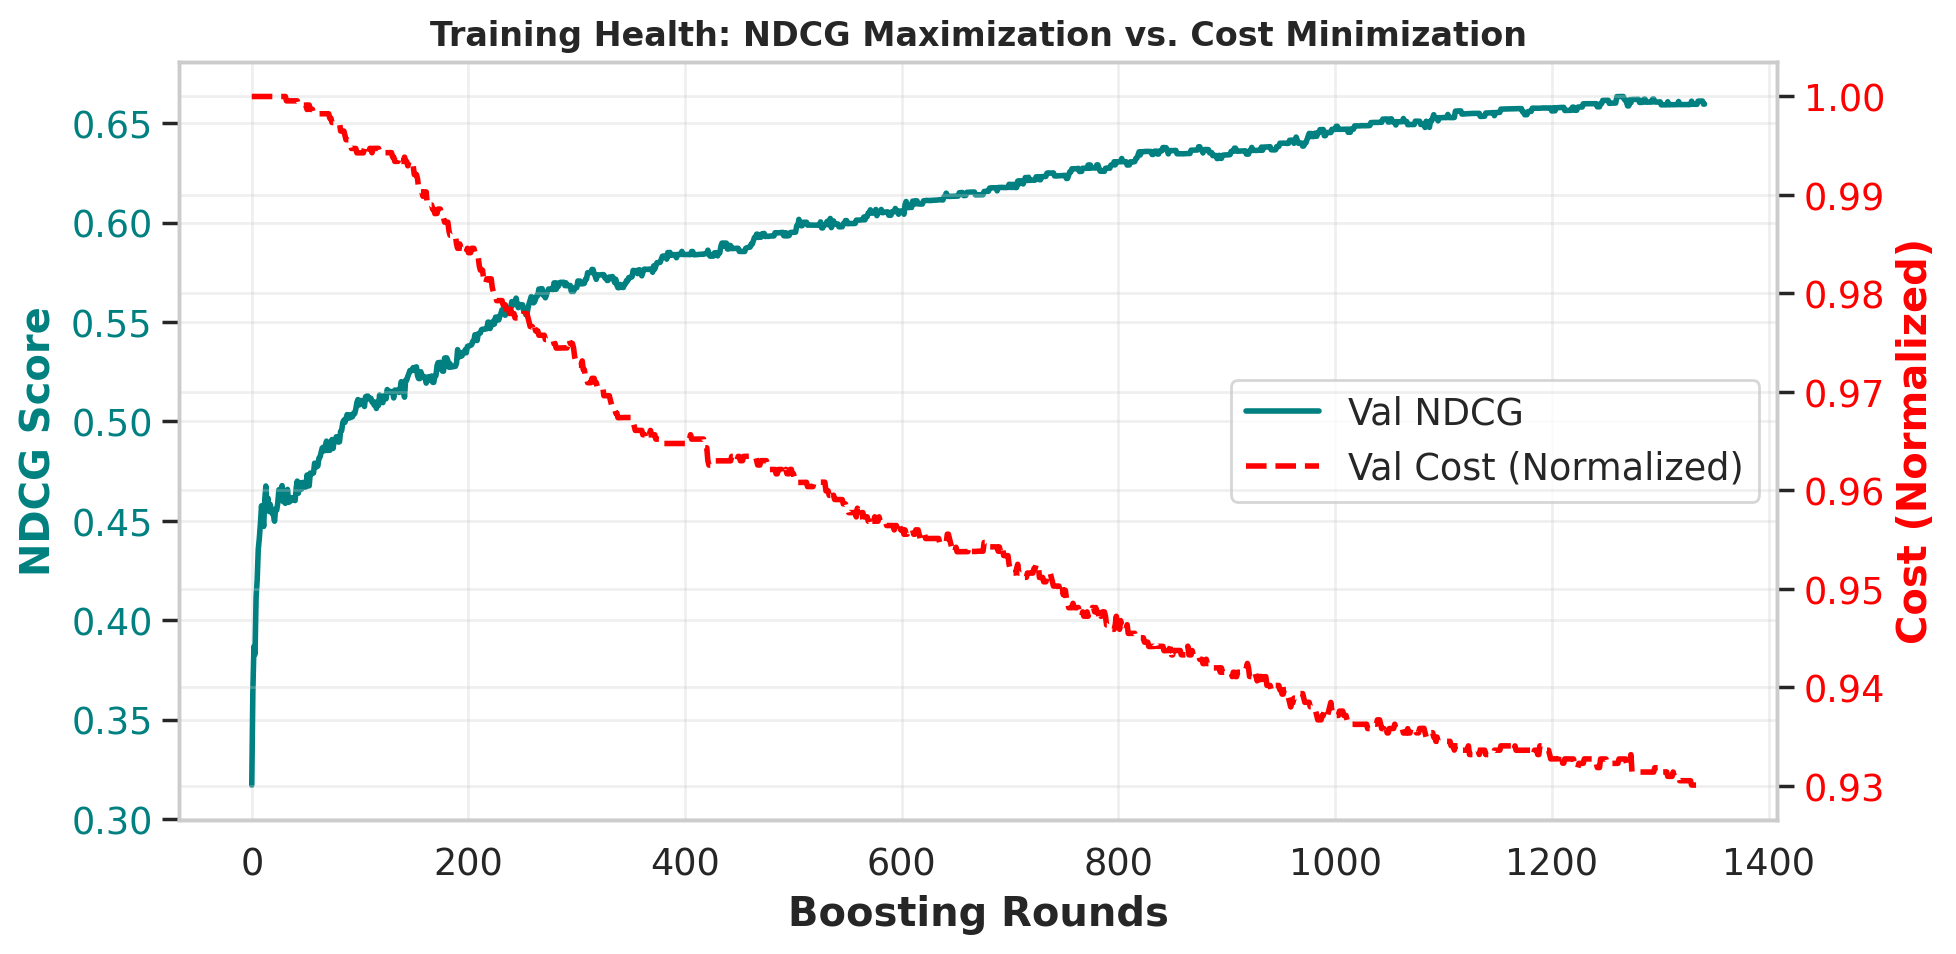

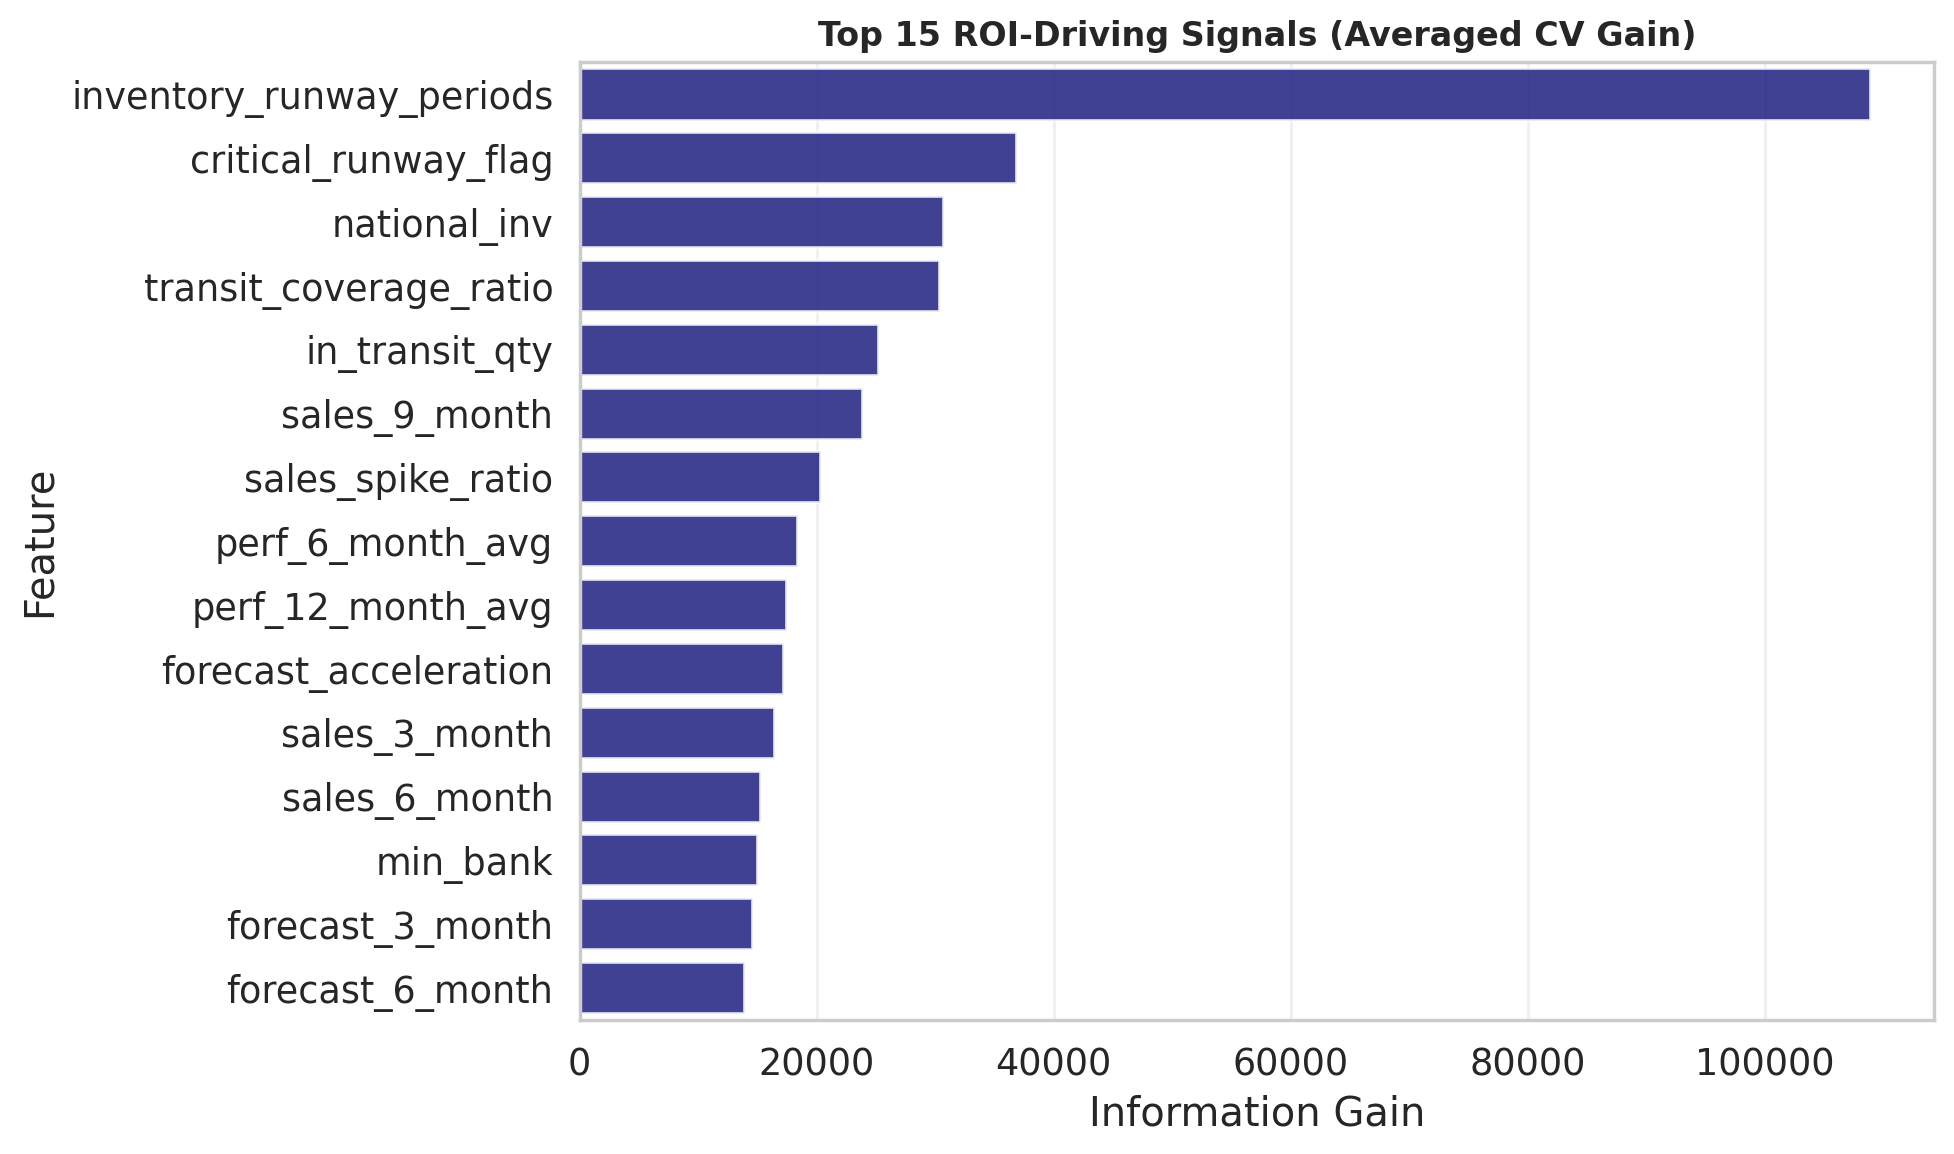

In [12]:
# ==============================================================================
# CELL 12: FINAL ENSEMBLE CV TRAINING & EVALUATION
# ==============================================================================
print("[*] Training Final CV Ensemble...")

# Train the model. The trainer handles the cross-validation loop internally.
oof_raw_margins, models, importance_df, eval_results = trainer.fit_cv(
    X=X_vital,
    y=y,
    weights=sample_weights,
    categorical_cols=active_categorical,
    params=best_params,
    num_boost_round=Config.N_BOOST_ROUNDS,
)

print("\n[*] Visualizing Training Health & Feature Importance...")
# Plot the learning curves from the last fold's evaluation dictionary
SupplyChainUtils.plot_training_health(eval_results)

# Plot the globally averaged feature importance across all CV folds
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Gain', y='Feature', color='darkblue', alpha=0.8)
plt.title(f"Top 15 ROI-Driving Signals (Averaged CV Gain)", fontsize=12, fontweight='bold')
plt.xlabel("Information Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## PHASE 5: MONETIZATION & SAFETY STOCK ENGINE
We use Conformal Prediction on the Out-Of-Fold (OOF) probabilities to calculate exact,
mathematically guaranteed safety stock buffers for the supply chain managers.

[SC_Core] INFO: Conformal Calibration [Alpha=0.05]: Threshold = 0.0769


[*] Initializing Safety Stock Engine (Conformal Prediction)...

--- SAFETY STOCK ALLOCATION SAMPLES (Danger Zone) ---


,Risk_Probability,Risk_Multiplier,Recommended_Safety_Stock,Actual_Backorder
1542939,0.2229,2.8991,6454272.0000,0.0000
974599,0.1532,1.9926,4436095.0000,0.0000
957096,0.0948,1.2332,2745633.0000,0.0000
269092,0.0913,1.1876,2644002.0000,0.0000
511965,0.0910,1.1838,2635491.0000,0.0000
96294,0.0899,1.1692,2485638.0000,0.0000
1416050,0.0851,1.1074,2445496.0000,0.0000
842690,0.0853,1.1099,2428754.0000,0.0000
1602060,0.0784,1.0197,2254570.0000,0.0000
384211,0.0794,1.0326,2253636.0000,0.0000



[*] Rendering Safety Stock Distribution...


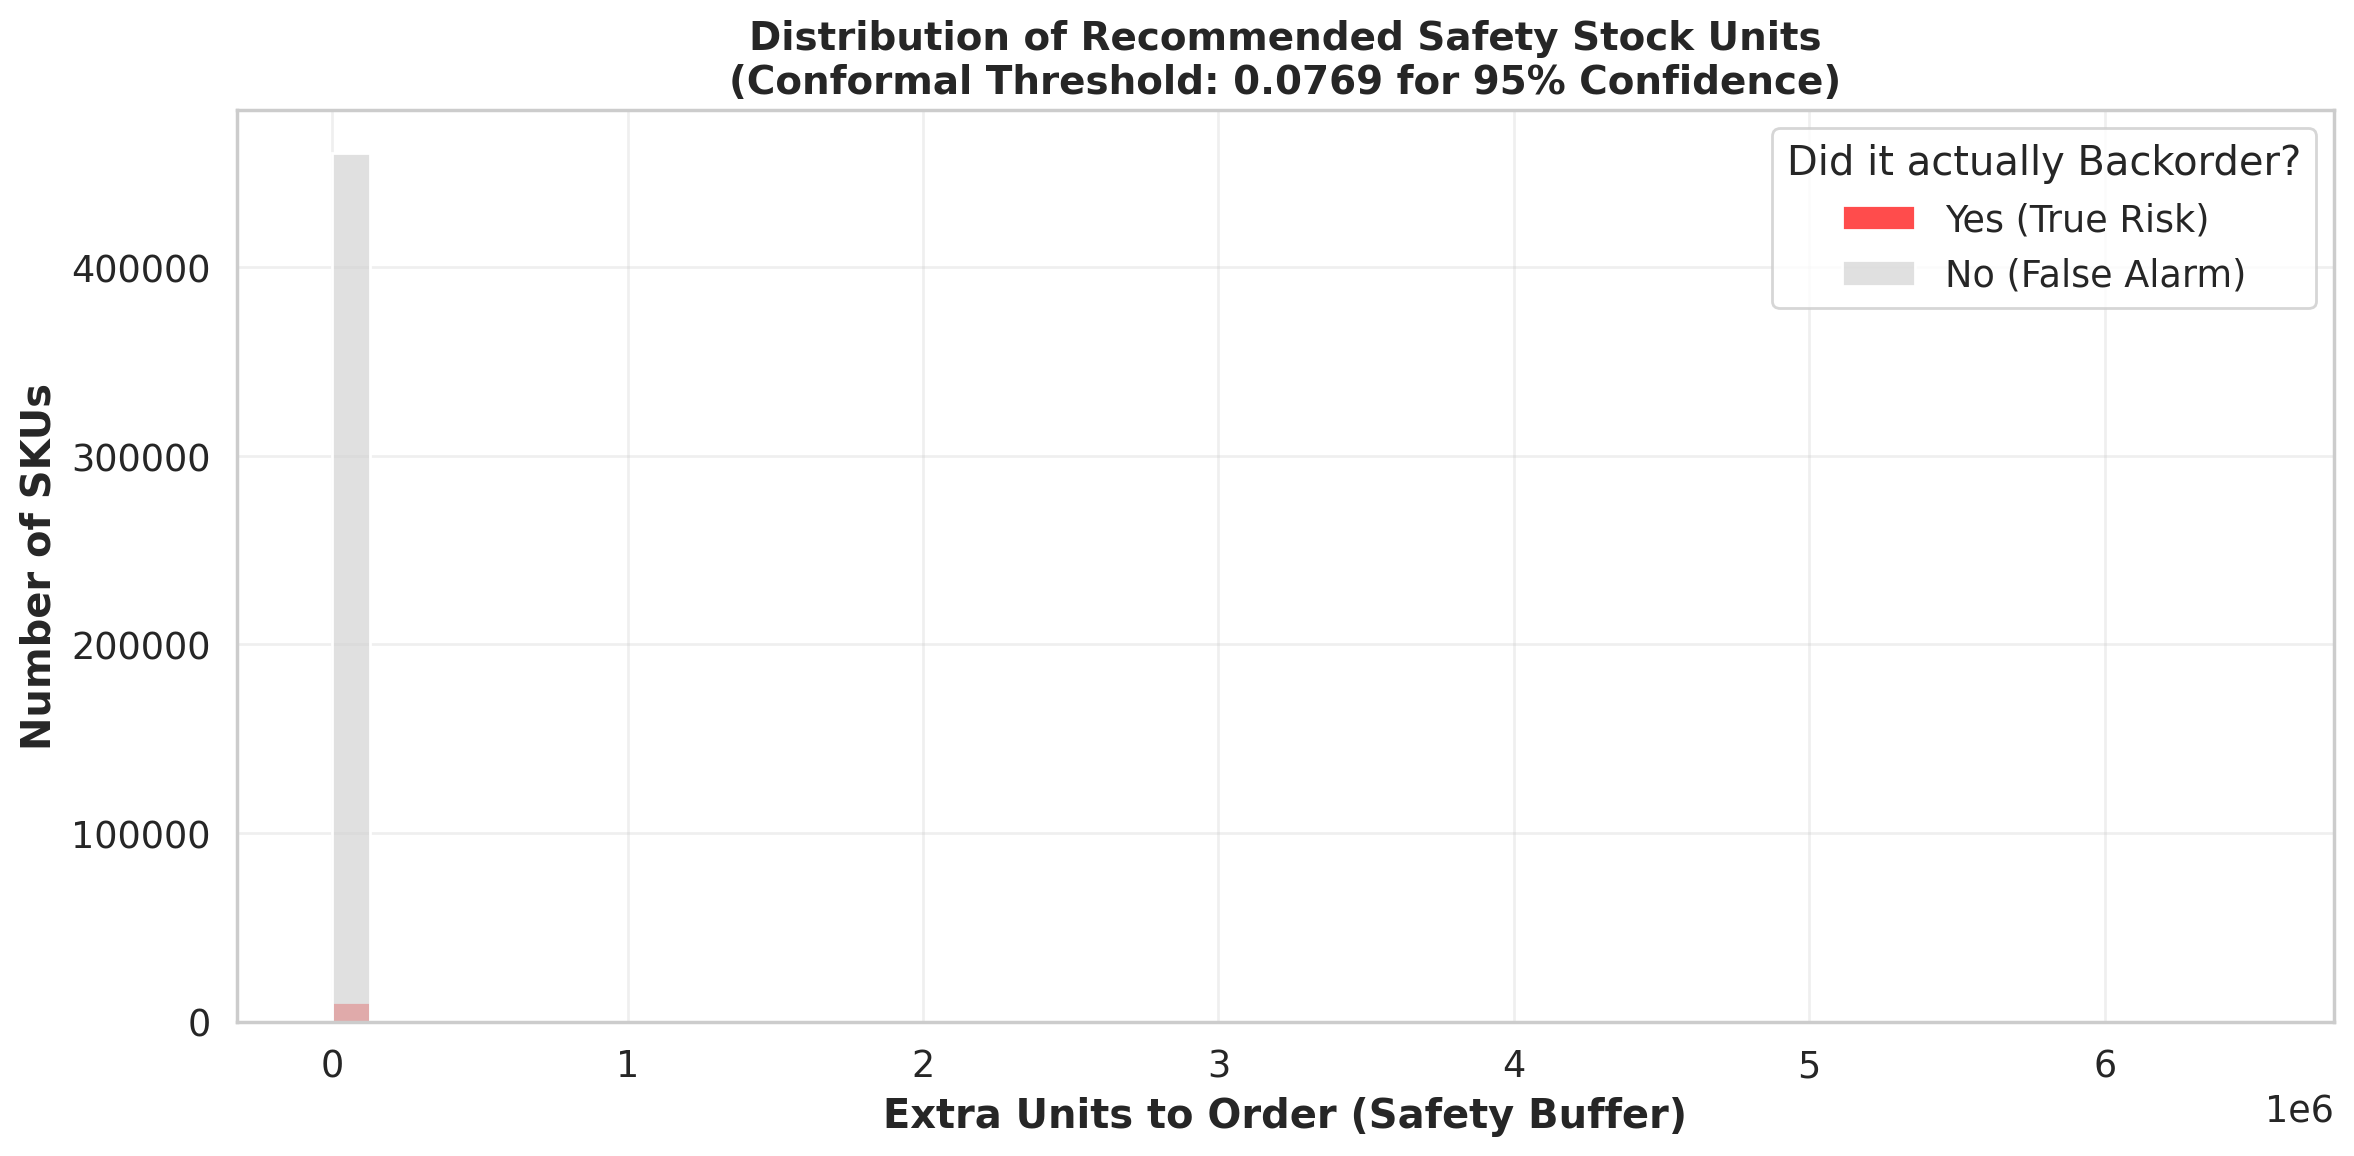

In [13]:
# ==============================================================================
# CELL 13: THE CONFORMAL SAFETY STOCK ENGINE
# ==============================================================================
from supply_chain_pred_core import ConformalInventoryEngine
from scipy.special import expit

print("[*] Initializing Safety Stock Engine (Conformal Prediction)...")
inventory_engine = ConformalInventoryEngine(alpha=0.05) # Aiming for 95% Coverage

# Convert the raw margins (logits) from our custom focal loss into probabilities
oof_probs = expit(oof_raw_margins)

# Calibrate the threshold strictly on the out-of-fold data to prevent overconfidence
inventory_engine.calibrate(oof_probs, y.values)

# Calculate specific inventory unit buffers
buffer_df = inventory_engine.allocate_buffers(
    df_features=X_vital,
    probs=oof_probs,
    velocity_col='sales_3_month',
    lead_time_col='lead_time',
    lead_time_scale=0.25 # Convert lead_time from weeks to months to match velocity
)

buffer_df['Actual_Backorder'] = y.values

print("\n--- SAFETY STOCK ALLOCATION SAMPLES (Danger Zone) ---")
danger_zone = buffer_df[buffer_df['Conformal_Flag'] == 1].sort_values(by='Recommended_Safety_Stock', ascending=False)

try:
    from IPython.display import display
    display(danger_zone[['Risk_Probability', 'Risk_Multiplier', 'Recommended_Safety_Stock', 'Actual_Backorder']].head(10))
except ImportError:
    print(danger_zone[['Risk_Probability', 'Risk_Multiplier', 'Recommended_Safety_Stock', 'Actual_Backorder']].head(10))

print("\n[*] Rendering Safety Stock Distribution...")
# Fallback visualization if plot_safety_stock_distribution wasn't explicitly added to Utils
plt.figure(figsize=(12, 6))
sns.histplot(
    data=danger_zone, x='Recommended_Safety_Stock', hue='Actual_Backorder',
    bins=50, multiple='layer', palette={0: 'lightgrey', 1: 'red'},
    edgecolor='white', alpha=0.7
)
plt.title(f"Distribution of Recommended Safety Stock Units\n(Conformal Threshold: {inventory_engine.tau_hat:.4f} for 95% Confidence)", fontsize=14, fontweight='bold')
plt.xlabel("Extra Units to Order (Safety Buffer)", fontweight='bold')
plt.ylabel("Number of SKUs", fontweight='bold')
plt.legend(title='Did it actually Backorder?', labels=['Yes (True Risk)', 'No (False Alarm)'])
plt.tight_layout()
plt.show()

In [14]:
# ==============================================================================
# CELL 14: GOVERNANCE EXPORT
# ==============================================================================
print("\n=== GLOBAL SCHEMA REGISTRY: FINAL CONTRACT REPORT ===")
inventory = global_schema_registry.export_inventory()

try:
    display(inventory['contracts'].head(25))
except ImportError:
    print(inventory['contracts'].head(25))

print("\n=== SYSTEM EXECUTION COMPLETE: THE ENGINE IS PRODUCTION-READY ===")


=== GLOBAL SCHEMA REGISTRY: FINAL CONTRACT REPORT ===


,Feature,Dependencies,DType_Family,Min_Val,Max_Val
0,sku,,categorical,NaN,NaN
1,went_on_backorder,,numeric,0.0000,1.0000
2,national_inv,,numeric,NaN,NaN
3,lead_time,,numeric,0.0000,NaN
4,in_transit_qty,,numeric,0.0000,NaN
5,sales_1_month,,numeric,0.0000,NaN
6,sales_3_month,,numeric,0.0000,NaN
7,sales_9_month,,numeric,0.0000,NaN
8,forecast_3_month,,numeric,0.0000,NaN
9,forecast_9_month,,numeric,0.0000,NaN



=== SYSTEM EXECUTION COMPLETE: THE ENGINE IS PRODUCTION-READY ===
